# MAX30102 Log Analysis (RAW LOGGER)

Notebook này kiểm tra nhanh luồng dữ liệu từ firmware logger:
- Đọc file log CSV từ ESP32
- Parse và làm sạch dữ liệu
- Plot tín hiệu IR/RED/power theo thời gian
- Cắt window 8s, stride 2s
- Trích feature theo cùng style với `ppg_dalia.ipynb`
- Đánh giá phân bố feature và độ ổn định sơ bộ

In [24]:
import sys
import subprocess

REQUIRED_PACKAGES = [
    "numpy",
    "pandas",
    "matplotlib",
    "scipy",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *REQUIRED_PACKAGES])
print("✅ Packages ready")

✅ Packages ready


In [5]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal
from scipy.signal import butter, filtfilt, welch, find_peaks

print("Python:", sys.version.split()[0])
print("CWD:", os.getcwd())

Python: 3.11.9
CWD: c:\ml\kaggle-ml-basics


In [6]:
# Tự động chọn thư mục experiment version mới nhất trong log/, ưu tiên exp_v2 trở lên
LOG_ROOT = Path(r"C:/ml/kaggle-ml-basics/log")
PREFERRED_EXP_VERSION = None  # ví dụ: "exp_v2" để pin cứng; để None sẽ auto chọn mới nhất

assert LOG_ROOT.exists(), f"Không tìm thấy thư mục log root: {LOG_ROOT}"

legacy_re = re.compile(r"^profile_(?P<profile_name>.+?)_(?P<condition>good|bad)_(?P<run_idx>\d+)\.csv$")
v2_re = re.compile(r"^(?P<condition>good|bad)_(?P<run_idx>\d+)\.csv$")
ver_re = re.compile(r"^exp_v(?P<v>\d+)$")

def pick_experiment_dir(log_root: Path, preferred: str | None = None) -> Path:
    if preferred is not None:
        p = log_root / preferred
        assert p.exists(), f"Không tìm thấy experiment dir được chỉ định: {p}"
        return p

    candidates = []
    for p in log_root.iterdir():
        if not p.is_dir():
            continue
        m = ver_re.match(p.name.lower())
        if m:
            candidates.append((int(m.group("v")), p))

    assert len(candidates) > 0, "Không tìm thấy thư mục dạng exp_v* trong log/"
    candidates.sort(key=lambda x: x[0])
    return candidates[-1][1]

def normalize_mode(mode_name: str) -> str:
    m = mode_name.lower()
    if m.startswith("adaptive") or m == "adaptive":
        return "adaptive"
    if "100" in m:
        return "fixed_100"
    if "50" in m and "low" in m:
        return "fixed_50_low"
    if "50" in m:
        return "fixed_50_med"
    return m

def infer_profile_from_mode(mode_name: str) -> str:
    m = mode_name.lower()
    if "adaptive" in m:
        return "adaptive_50_100"
    if "100" in m:
        return "100sps_med"
    if "50" in m and "low" in m:
        return "50sps_low"
    if "50" in m:
        return "50sps_med"
    return m

EXP_DIR = pick_experiment_dir(LOG_ROOT, PREFERRED_EXP_VERSION)
print(f"Using experiment dir: {EXP_DIR}")

records = []
for fp in sorted(EXP_DIR.rglob("*.csv")):
    exp_mode = fp.parent.name.lower()
    file_name = fp.name

    m_legacy = legacy_re.match(file_name)
    m_v2 = v2_re.match(file_name)

    if m_legacy is not None:
        profile_name = m_legacy.group("profile_name")
        condition = m_legacy.group("condition")
        run_idx = int(m_legacy.group("run_idx"))
    elif m_v2 is not None:
        profile_name = infer_profile_from_mode(exp_mode)
        condition = m_v2.group("condition")
        run_idx = int(m_v2.group("run_idx"))
    else:
        continue

    records.append({
        "file_path": fp,
        "file_name": file_name,
        "profile_name": profile_name,
        "condition": condition,
        "run_idx": run_idx,
        "exp_mode": exp_mode,
        "exp_group": normalize_mode(exp_mode),
        "exp_version": EXP_DIR.name,
        "group_dir": fp.parent.name,
    })

experiment_df = pd.DataFrame(records).sort_values(["exp_mode", "condition", "run_idx", "file_name"]).reset_index(drop=True)
assert len(experiment_df) > 0, f"Không tìm thấy file log parseable trong {EXP_DIR}"

print("Found experiment files:", len(experiment_df))
display(experiment_df)

expected_runs = experiment_df.groupby(["exp_mode", "condition"]).size().rename("n_runs").reset_index()
print("\nRun count per mode-condition:")
display(expected_runs)

Using experiment dir: C:\ml\kaggle-ml-basics\log\exp_v7
Found experiment files: 13


,file_path,file_name,profile_name,condition,run_idx,exp_mode,exp_group,exp_version,group_dir
0,C:\ml\kaggle-ml-basics\log\exp_v7\adaptive_50_...,bad_01.csv,adaptive_50_100,bad,1,adaptive_50_100,adaptive,exp_v7,adaptive_50_100
1,C:\ml\kaggle-ml-basics\log\exp_v7\adaptive_50_...,bad_02.csv,adaptive_50_100,bad,2,adaptive_50_100,adaptive,exp_v7,adaptive_50_100
2,C:\ml\kaggle-ml-basics\log\exp_v7\adaptive_50_...,good_01.csv,adaptive_50_100,good,1,adaptive_50_100,adaptive,exp_v7,adaptive_50_100
3,C:\ml\kaggle-ml-basics\log\exp_v7\adaptive_50_...,good_02.csv,adaptive_50_100,good,2,adaptive_50_100,adaptive,exp_v7,adaptive_50_100
4,C:\ml\kaggle-ml-basics\log\exp_v7\adaptive_50_...,good_03.csv,adaptive_50_100,good,3,adaptive_50_100,adaptive,exp_v7,adaptive_50_100
5,C:\ml\kaggle-ml-basics\log\exp_v7\fixed_100_me...,bad_01.csv,100sps_med,bad,1,fixed_100_med,fixed_100,exp_v7,fixed_100_med
6,C:\ml\kaggle-ml-basics\log\exp_v7\fixed_100_me...,bad_02.csv,100sps_med,bad,2,fixed_100_med,fixed_100,exp_v7,fixed_100_med
7,C:\ml\kaggle-ml-basics\log\exp_v7\fixed_100_me...,good_01.csv,100sps_med,good,1,fixed_100_med,fixed_100,exp_v7,fixed_100_med
8,C:\ml\kaggle-ml-basics\log\exp_v7\fixed_100_me...,good_02.csv,100sps_med,good,2,fixed_100_med,fixed_100,exp_v7,fixed_100_med
9,C:\ml\kaggle-ml-basics\log\exp_v7\fixed_50_med...,bad_01.csv,50sps_med,bad,1,fixed_50_med,fixed_50_med,exp_v7,fixed_50_med



Run count per mode-condition:


,exp_mode,condition,n_runs
0,adaptive_50_100,bad,2
1,adaptive_50_100,good,3
2,fixed_100_med,bad,2
3,fixed_100_med,good,2
4,fixed_50_med,bad,2
5,fixed_50_med,good,2


In [7]:
def parse_logger_file(path: Path):
    rows = []
    total_lines = 0
    matched_lines = 0

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            total_lines += 1
            s = line.strip()
            if not s or s.startswith("I (") or "SYS_DEMO:" in s:
                continue

            parts = s.split(",")
            if len(parts) == 7:
                try:
                    rows.append({
                        "timestamp_ms": int(parts[0]),
                        "state_id": -1,
                        "profile_id": int(parts[1]),
                        "quality_pass": np.nan,
                        "difficulty_proxy": np.nan,
                        "red": int(parts[2]),
                        "ir": int(parts[3]),
                        "bus_v": float(parts[4]),
                        "current_ma": float(parts[5]),
                        "power_mw": float(parts[6]),
                    })
                    matched_lines += 1
                except ValueError:
                    continue
            elif len(parts) == 10:
                try:
                    rows.append({
                        "timestamp_ms": int(parts[0]),
                        "state_id": int(parts[1]),
                        "profile_id": int(parts[2]),
                        "quality_pass": int(parts[3]),
                        "difficulty_proxy": float(parts[4]),
                        "red": int(parts[5]),
                        "ir": int(parts[6]),
                        "bus_v": float(parts[7]),
                        "current_ma": float(parts[8]),
                        "power_mw": float(parts[9]),
                    })
                    matched_lines += 1
                except ValueError:
                    continue

    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise ValueError(f"Không parse được dòng CSV nào từ file: {path}")

    df = df.sort_values("timestamp_ms").drop_duplicates(subset=["timestamp_ms"], keep="last").reset_index(drop=True)
    df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0
    df["dt_s"] = df["time_s"].diff().fillna(0.0)
    return df, total_lines, matched_lines

all_raw_parts = []
file_stats = []

for _, row in experiment_df.iterrows():
    df_one, total_lines, matched_lines = parse_logger_file(Path(row["file_path"]))
    dt = df_one["dt_s"].values
    dt = dt[dt > 1e-6]
    fs_est = 1.0 / np.median(dt) if len(dt) else np.nan

    df_one["file_name"] = row["file_name"]
    df_one["profile_name"] = row["profile_name"]
    df_one["condition"] = row["condition"]
    df_one["run_idx"] = row["run_idx"]
    df_one["exp_mode"] = row["exp_mode"]
    df_one["exp_group"] = row["exp_group"]
    df_one["exp_version"] = row["exp_version"]
    all_raw_parts.append(df_one)

    file_stats.append({
        "file_name": row["file_name"],
        "exp_mode": row["exp_mode"],
        "exp_group": row["exp_group"],
        "profile_name": row["profile_name"],
        "condition": row["condition"],
        "run_idx": row["run_idx"],
        "rows_raw": len(df_one),
        "duration_s": float(df_one["time_s"].iloc[-1]),
        "fs_est_hz": float(fs_est) if np.isfinite(fs_est) else np.nan,
        "matched_csv_rows": matched_lines,
        "total_lines": total_lines,
        "profile_ids_in_file": ",".join(map(str, sorted(df_one["profile_id"].unique().tolist()))),
        "state_ids_in_file": ",".join(map(str, sorted(df_one["state_id"].dropna().astype(int).unique().tolist()))),
    })

raw_df = pd.concat(all_raw_parts, ignore_index=True)
file_stats_df = pd.DataFrame(file_stats).sort_values(["exp_mode", "condition", "run_idx", "file_name"]).reset_index(drop=True)

print("Total rows across all files:", len(raw_df))
display(file_stats_df)
display(raw_df.head())

Total rows across all files: 157366


,file_name,exp_mode,exp_group,profile_name,condition,run_idx,rows_raw,duration_s,fs_est_hz,matched_csv_rows,total_lines,profile_ids_in_file,state_ids_in_file
0,bad_01.csv,adaptive_50_100,adaptive,adaptive_50_100,bad,1,12051,120.598,100.0,12051,12123,"0,2","0,1"
1,bad_02.csv,adaptive_50_100,adaptive,adaptive_50_100,bad,2,12329,123.359,100.0,12329,12401,"0,2","0,1"
2,good_01.csv,adaptive_50_100,adaptive,adaptive_50_100,good,1,11930,120.319,100.0,11930,12022,"0,2","0,1"
3,good_02.csv,adaptive_50_100,adaptive,adaptive_50_100,good,2,12167,122.695,100.0,12167,12259,"0,2","0,1"
4,good_03.csv,adaptive_50_100,adaptive,adaptive_50_100,good,3,12008,120.748,100.0,12008,12092,"0,2","0,1"
5,bad_01.csv,fixed_100_med,fixed_100,100sps_med,bad,1,12018,120.195,100.0,12018,12018,0,1
6,bad_02.csv,fixed_100_med,fixed_100,100sps_med,bad,2,12040,120.425,100.0,12040,12040,0,1
7,good_01.csv,fixed_100_med,fixed_100,100sps_med,good,1,12494,124.971,100.0,12494,12494,0,1
8,good_02.csv,fixed_100_med,fixed_100,100sps_med,good,2,12129,121.310,100.0,12129,12129,0,1
9,bad_01.csv,fixed_50_med,fixed_50_med,50sps_med,bad,1,12030,120.317,100.0,12030,12030,2,0


,timestamp_ms,state_id,profile_id,quality_pass,difficulty_proxy,red,ir,bus_v,current_ma,power_mw,time_s,dt_s,file_name,profile_name,condition,run_idx,exp_mode,exp_group,exp_version
0,177,0,2,1,0.5,4752,4298,3.212,3.4,10.921,0.000,0.000,bad_01.csv,adaptive_50_100,bad,1,adaptive_50_100,adaptive,exp_v7
1,180,0,2,1,0.5,4893,4605,3.212,3.4,10.921,0.003,0.003,bad_01.csv,adaptive_50_100,bad,1,adaptive_50_100,adaptive,exp_v7
2,184,0,2,1,0.5,6375,6296,3.212,3.4,10.921,0.007,0.004,bad_01.csv,adaptive_50_100,bad,1,adaptive_50_100,adaptive,exp_v7
3,190,0,2,1,0.5,11186,11591,3.212,3.4,10.921,0.013,0.006,bad_01.csv,adaptive_50_100,bad,1,adaptive_50_100,adaptive,exp_v7
4,200,0,2,1,0.5,32807,32416,3.212,3.4,10.921,0.023,0.010,bad_01.csv,adaptive_50_100,bad,1,adaptive_50_100,adaptive,exp_v7


In [8]:
# Chẩn đoán raw adaptive: vì sao good dễ fail và bad lại pass
adaptive_raw = raw_df[(raw_df["exp_group"] == "adaptive") & (raw_df["state_id"] >= 0)].copy()

if len(adaptive_raw) == 0:
    print("Không có adaptive rows hợp lệ để chẩn đoán raw transition")
else:
    adaptive_raw = adaptive_raw.sort_values(["file_name", "timestamp_ms"]).reset_index(drop=True)
    adaptive_raw["elapsed_s"] = adaptive_raw.groupby("file_name")["time_s"].transform(lambda s: s - s.min())
    adaptive_raw["phase"] = np.where(adaptive_raw["elapsed_s"] <= 8.0, "early_0_8s", "late_after_8s")

    q_state_phase = adaptive_raw.groupby(["condition", "phase", "state_id"]).agg(
        rows=("quality_pass", "size"),
        quality_pass_ratio=("quality_pass", "mean"),
        difficulty_proxy_mean=("difficulty_proxy", "mean"),
        ir_mean=("ir", "mean"),
        ir_ptp=("ir", lambda x: float(np.ptp(x.values.astype(np.float64)))),
    ).reset_index().sort_values(["condition", "phase", "state_id"])

    print("=== Adaptive quality ratio by condition/phase/state ===")
    display(q_state_phase)

    transition_rows = []
    for (cond, fn), g in adaptive_raw.groupby(["condition", "file_name"]):
        g = g.sort_values("timestamp_ms").reset_index(drop=True)
        prev_state = g["state_id"].shift(1)
        curr_state = g["state_id"]
        trans = g[(prev_state == 0) & (curr_state == 1)]
        first_switch_s = float(trans["elapsed_s"].iloc[0]) if len(trans) else np.nan
        first_switch_quality = int(trans["quality_pass"].iloc[0]) if len(trans) else np.nan
        transition_rows.append({
            "condition": cond,
            "file_name": fn,
            "first_switch_to_high_s": first_switch_s,
            "quality_at_switch": first_switch_quality,
            "late_quality_pass_ratio": float(g[g["phase"] == "late_after_8s"]["quality_pass"].mean()),
            "late_state1_ratio": float((g[g["phase"] == "late_after_8s"]["state_id"] == 1).mean()),
        })

    transition_df = pd.DataFrame(transition_rows).sort_values(["condition", "file_name"])
    print("\n=== First NORMAL->HIGH switch diagnostics ===")
    display(transition_df)

    print("\n=== Condition-level transition summary ===")
    cond_transition_summary = transition_df.groupby("condition").agg(
        n_files=("file_name", "count"),
        switch_time_mean_s=("first_switch_to_high_s", "mean"),
        switch_time_std_s=("first_switch_to_high_s", "std"),
        late_quality_pass_ratio_mean=("late_quality_pass_ratio", "mean"),
        late_state1_ratio_mean=("late_state1_ratio", "mean"),
    ).reset_index()
    display(cond_transition_summary)

=== Adaptive quality ratio by condition/phase/state ===


,condition,phase,state_id,rows,quality_pass_ratio,difficulty_proxy_mean,ir_mean,ir_ptp
0,bad,early_0_8s,0,598,1.000000,0.424749,45459.123746,89854.0
1,bad,early_0_8s,1,988,0.000000,1.000000,24278.842105,138663.0
2,bad,late_after_8s,1,22794,0.000000,0.989541,55212.588444,155313.0
3,good,early_0_8s,0,1800,1.000000,0.452504,80385.742222,28800.0
4,good,early_0_8s,1,588,0.000000,0.904320,122466.918367,78557.0
5,good,late_after_8s,0,14797,0.905386,0.470257,79658.458742,77400.0
6,good,late_after_8s,1,18920,0.581871,0.556453,120930.833721,82394.0



=== First NORMAL->HIGH switch diagnostics ===


,condition,file_name,first_switch_to_high_s,quality_at_switch,late_quality_pass_ratio,late_state1_ratio
0,bad,bad_01.csv,2.077,0,0.000000,1.000000
1,bad,bad_02.csv,4.077,0,0.000000,1.000000
2,good,good_01.csv,10.077,0,0.646747,0.676761
3,good,good_02.csv,4.077,0,0.650607,0.613153
4,good,good_03.csv,6.077,0,0.874632,0.393669



=== Condition-level transition summary ===


,condition,n_files,switch_time_mean_s,switch_time_std_s,late_quality_pass_ratio_mean,late_state1_ratio_mean
0,bad,2,3.077000,1.414214,0.000000,1.000000
1,good,3,6.743667,3.055050,0.723995,0.561194


=== Per-file sampling summary ===


,file_name,profile_name,condition,rows_raw,duration_s,fs_est_hz,profile_ids_in_file,state_ids_in_file
0,bad_01.csv,adaptive_50_100,bad,10285,102.948,100.0,"0,2","0,1"
1,bad_02.csv,adaptive_50_100,bad,12020,120.304,100.0,"0,2","0,1"
2,good_01.csv,adaptive_50_100,good,11990,120.387,100.0,"0,2","0,1"
3,good_02.csv,adaptive_50_100,good,11976,120.412,100.0,"0,2","0,1"
4,bad_01.csv,100sps_med,bad,12040,120.425,100.0,0,1
5,bad_02.csv,100sps_med,bad,12089,120.913,100.0,0,1
6,good_01.csv,100sps_med,good,12310,123.109,100.0,0,1
7,good_02.csv,100sps_med,good,12129,121.310,100.0,0,1
8,bad_01.csv,50sps_med,bad,12030,120.317,100.0,2,0
9,bad_02.csv,50sps_med,bad,9001,90.015,100.0,2,0



=== Profile-condition summary ===


,profile_name,condition,n_files,duration_mean_s,fs_mean_hz,fs_std_hz
0,100sps_med,bad,2,120.6690,100.0,0.0
1,100sps_med,good,2,122.2095,100.0,0.0
2,50sps_med,bad,2,105.1660,100.0,0.0
3,50sps_med,good,2,120.6020,100.0,0.0
4,adaptive_50_100,bad,2,111.6260,100.0,0.0
5,adaptive_50_100,good,2,120.3995,100.0,0.0


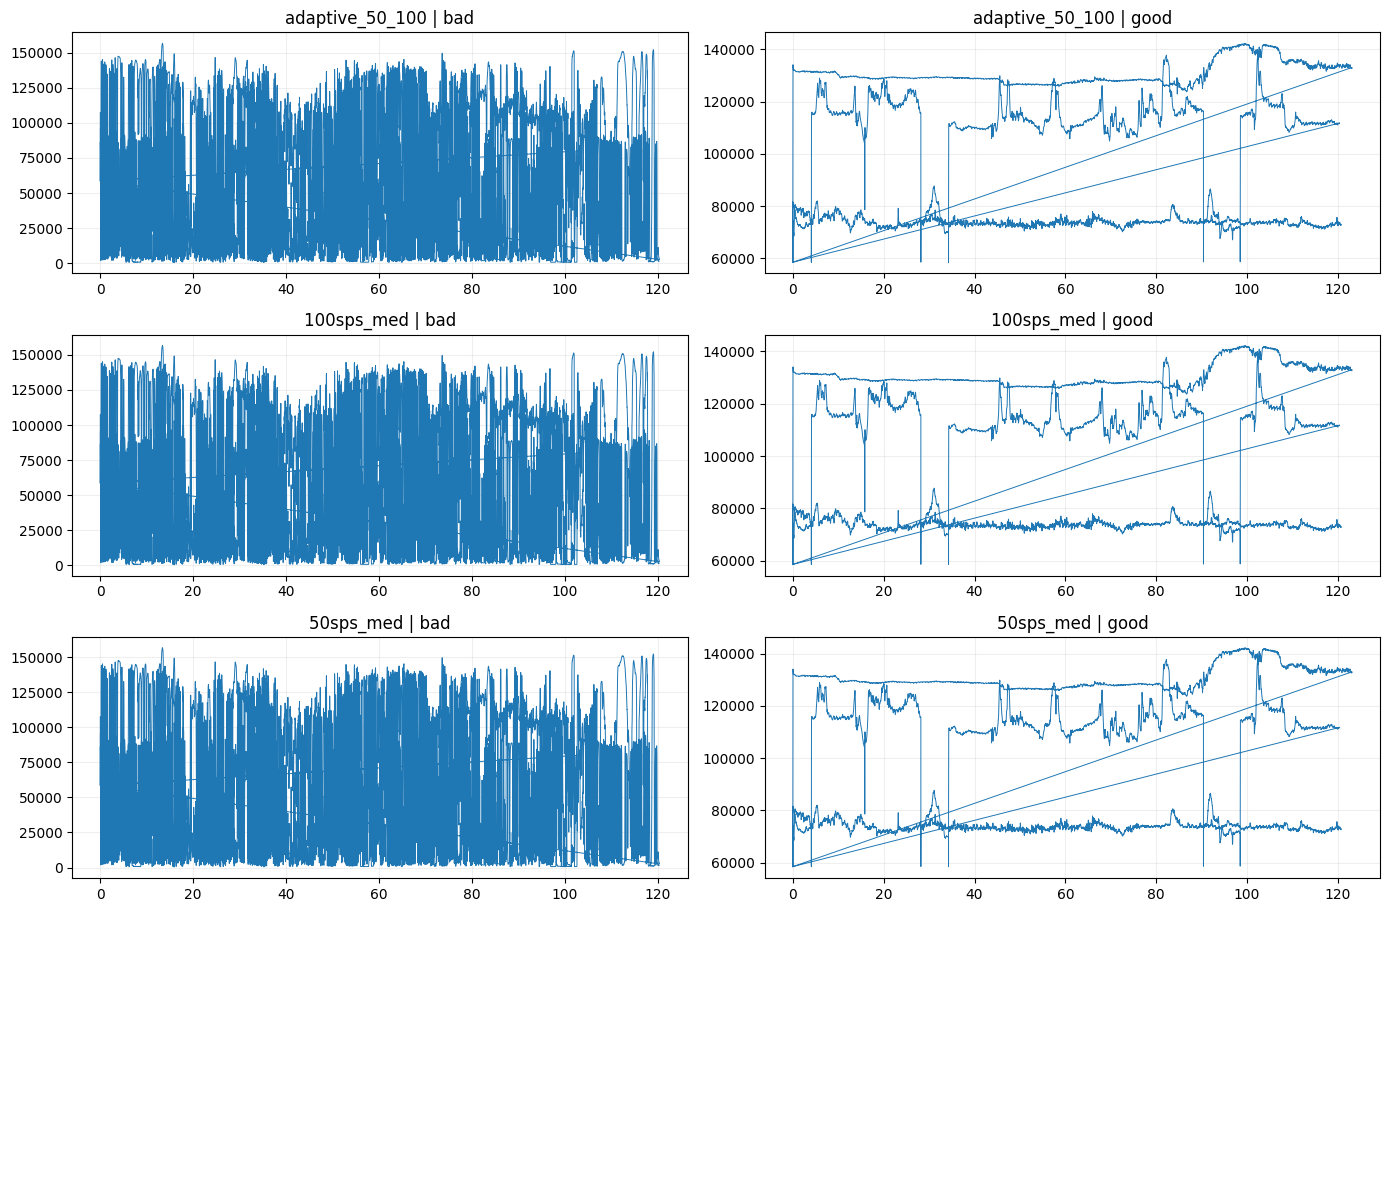

In [69]:
print("=== Per-file sampling summary ===")
display(file_stats_df[["file_name", "profile_name", "condition", "rows_raw", "duration_s", "fs_est_hz", "profile_ids_in_file", "state_ids_in_file"]])

summary_by_profile = file_stats_df.groupby(["profile_name", "condition"]).agg(
    n_files=("file_name", "count"),
    duration_mean_s=("duration_s", "mean"),
    fs_mean_hz=("fs_est_hz", "mean"),
    fs_std_hz=("fs_est_hz", "std"),
).reset_index()

print("\n=== Profile-condition summary ===")
display(summary_by_profile)

# Plot quick-look cho 1 file đại diện mỗi profile x condition
fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=False)
axes = axes.ravel()
pairs = file_stats_df[["profile_name", "condition"]].drop_duplicates().values.tolist()

for idx, (profile_name, condition) in enumerate(pairs[:len(axes)]):
    rep_file = file_stats_df[(file_stats_df["profile_name"] == profile_name) & (file_stats_df["condition"] == condition)].iloc[0]["file_name"]
    df_rep = raw_df[raw_df["file_name"] == rep_file]
    ax = axes[idx]
    ax.plot(df_rep["time_s"], df_rep["ir"], linewidth=0.7)
    ax.set_title(f"{profile_name} | {condition}")
    ax.grid(alpha=0.2)

for j in range(len(pairs), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [9]:
def safe_nan_to_num(x):
    x = np.asarray(x, dtype=np.float32)
    return np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

def detrend_signal(x):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < 3:
        return x.copy()
    return signal.detrend(x).astype(np.float32)

def butter_bandpass_filter(x, fs, lowcut=0.7, highcut=5.0, order=3):
    x = np.asarray(x, dtype=np.float32)
    nyq = 0.5 * fs
    low = max(0.001, lowcut / nyq)
    high = min(0.99, highcut / nyq)
    if low >= high:
        return x.copy()
    b, a = butter(order, [low, high], btype="band")
    if len(x) < max(len(a), len(b)) * 3:
        return x.copy()
    return filtfilt(b, a, x).astype(np.float32)

def robust_zscore(x):
    x = np.asarray(x, dtype=np.float32)
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    scale = 1.4826 * mad
    if scale < 1e-8:
        scale = np.std(x)
    if scale < 1e-8:
        scale = 1.0
    return ((x - med) / scale).astype(np.float32)

def preprocess_ppg(sig, fs):
    x_raw = safe_nan_to_num(sig)
    x_dt = detrend_signal(x_raw)
    x_bp = butter_bandpass_filter(x_dt, fs=fs, lowcut=0.7, highcut=5.0, order=3)
    x_norm = robust_zscore(x_bp)
    return x_raw, x_dt, x_bp, x_norm

def normalized_autocorr(x):
    x = np.asarray(x, dtype=np.float32)
    x = x - np.mean(x)
    denom = np.sum(x * x)
    if denom < 1e-8:
        return np.zeros(len(x), dtype=np.float32)
    ac = np.correlate(x, x, mode="full")
    ac = ac[len(x)-1:] / denom
    return ac.astype(np.float32)

def spectral_entropy_from_psd(psd):
    psd = np.asarray(psd, dtype=np.float64)
    psd = np.maximum(psd, 1e-12)
    psd = psd / np.sum(psd)
    return float(-np.sum(psd * np.log(psd)) / np.log(len(psd)))

def bandpower(freqs, psd, fmin, fmax):
    mask = (freqs >= fmin) & (freqs <= fmax)
    if np.sum(mask) == 0:
        return 0.0
    integrator = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
    return float(integrator(psd[mask], freqs[mask]))

def extract_ppg_features(sig_raw, fs):
    _, _, _, x = preprocess_ppg(sig_raw, fs)
    n = len(x)
    feats = {}

    dx = np.diff(x)
    feats["mean"] = float(np.mean(x))
    feats["std"] = float(np.std(x))
    feats["ptp"] = float(np.ptp(x))
    feats["rms"] = float(np.sqrt(np.mean(x**2)))
    feats["abs_mean"] = float(np.mean(np.abs(x)))
    feats["slope_abs_mean"] = float(np.mean(np.abs(dx))) if len(dx) > 0 else 0.0

    min_distance = max(1, int(fs * 0.33))
    prominence = max(0.05, 0.15 * np.std(x))
    peaks, peak_props = find_peaks(x, distance=min_distance, prominence=prominence)

    feats["n_peaks"] = float(len(peaks))
    feats["peak_rate_per_sec"] = float(len(peaks) / (n / fs)) if n > 0 else 0.0

    if len(peaks) >= 2:
        ibi = np.diff(peaks) / fs
        hr_inst = 60.0 / np.clip(ibi, 1e-6, None)
        feats["hr_est_mean"] = float(np.mean(hr_inst))
        feats["hr_est_std"] = float(np.std(hr_inst))
    else:
        feats["hr_est_mean"] = 0.0
        feats["hr_est_std"] = 0.0

    if len(peaks) > 0 and "prominences" in peak_props:
        feats["peak_prom_mean"] = float(np.mean(peak_props["prominences"]))
    else:
        feats["peak_prom_mean"] = 0.0

    ac = normalized_autocorr(x)
    lag_min = int(fs * 60 / 180)
    lag_max = min(int(fs * 60 / 40), len(ac) - 1)

    if lag_max > lag_min:
        ac_band = ac[lag_min:lag_max + 1]
        best_idx = np.argmax(ac_band)
        best_lag = lag_min + best_idx
        feats["ac_best"] = float(ac[best_lag])
        feats["ac_best_hr"] = float(60.0 / (best_lag / fs))
    else:
        feats["ac_best"] = 0.0
        feats["ac_best_hr"] = 0.0

    nperseg = min(256, len(x))
    if nperseg >= 32:
        freqs, psd = welch(x, fs=fs, nperseg=nperseg)
        psd = np.maximum(psd, 1e-12)
        total_power = bandpower(freqs, psd, 0.0, min(8.0, fs / 2))
        hr_power = bandpower(freqs, psd, 0.7, 3.5)
        feats["psd_hr_ratio"] = float(hr_power / (total_power + 1e-8))
        feats["spectral_entropy"] = spectral_entropy_from_psd(psd)

        hr_mask = (freqs >= 0.7) & (freqs <= 3.5)
        if np.sum(hr_mask) > 0:
            f_hr = freqs[hr_mask]
            p_hr = psd[hr_mask]
            feats["dom_bpm_hr_band"] = float(f_hr[np.argmax(p_hr)] * 60.0)
        else:
            feats["dom_bpm_hr_band"] = 0.0
    else:
        feats["psd_hr_ratio"] = 0.0
        feats["spectral_entropy"] = 0.0
        feats["dom_bpm_hr_band"] = 0.0

    for k, v in list(feats.items()):
        if isinstance(v, (float, np.floating)) and (np.isnan(v) or np.isinf(v)):
            feats[k] = 0.0

    return feats

In [10]:
WIN_SEC = 8.0
STRIDE_SEC = 2.0
TRANSIENT_DROP_SEC = 3.0
TIMING_P95_FACTOR = 2.5

# Dùng fs danh nghĩa theo profile_id vì timestamp logger bị burst khi drain FIFO
PROFILE_ID_TO_FS = {0: 100.0, 1: 50.0, 2: 50.0}

rows = []
skipped_timing = 0
skipped_short_segment = 0

for file_name, df_file in raw_df.groupby("file_name"):
    df_file = df_file.sort_values("timestamp_ms").reset_index(drop=True)

    df_work = df_file[df_file["time_s"] >= TRANSIENT_DROP_SEC].copy().reset_index(drop=True)
    if len(df_work) < 100:
        continue

    t0 = float(df_work["time_s"].min())
    t1 = float(df_work["time_s"].max())
    start_t = t0

    while (start_t + WIN_SEC) <= t1:
        end_t = start_t + WIN_SEC
        seg_df = df_work[(df_work["time_s"] >= start_t) & (df_work["time_s"] < end_t)].copy()

        if len(seg_df) < 40:
            skipped_short_segment += 1
            start_t += STRIDE_SEC
            continue

        seg_dt = seg_df["timestamp_ms"].diff().fillna(0).values / 1000.0
        valid_dt = seg_dt[seg_dt > 1e-6]
        timing_ok = True
        if len(valid_dt) > 0:
            timing_ok = np.percentile(valid_dt, 95) < TIMING_P95_FACTOR * np.median(valid_dt)
        if not timing_ok:
            skipped_timing += 1
            start_t += STRIDE_SEC
            continue

        profile_id_mode = int(seg_df["profile_id"].mode().iloc[0])
        fs_seg = float(PROFILE_ID_TO_FS.get(profile_id_mode, 50.0))

        sig_ir = seg_df["ir"].astype(np.float32).values
        sig_red = seg_df["red"].astype(np.float32).values
        feats = extract_ppg_features(sig_ir, fs=fs_seg)

        valid_state_ids = seg_df[seg_df["state_id"] >= 0]["state_id"]
        state_mode = int(valid_state_ids.mode().iloc[0]) if len(valid_state_ids) else -1

        item = {
            "file_name": file_name,
            "exp_mode": str(seg_df["exp_mode"].iloc[0]),
            "exp_group": str(seg_df["exp_group"].iloc[0]) if "exp_group" in seg_df.columns else str(seg_df["exp_mode"].iloc[0]),
            "exp_version": str(seg_df["exp_version"].iloc[0]) if "exp_version" in seg_df.columns else "unknown",
            "profile_name": str(seg_df["profile_name"].iloc[0]),
            "condition": str(seg_df["condition"].iloc[0]),
            "run_idx": int(seg_df["run_idx"].iloc[0]),
            "profile_id_mode": profile_id_mode,
            "state_id_mode": state_mode,
            "fs_file": fs_seg,
            "window_start_s": float(start_t),
            "window_end_s": float(end_t),
            "ir_raw_mean": float(np.mean(sig_ir)),
            "ir_raw_std": float(np.std(sig_ir)),
            "ir_raw_ptp": float(np.ptp(sig_ir)),
            "red_raw_std": float(np.std(sig_red)),
            "power_mw_mean": float(seg_df["power_mw"].mean()),
            "power_mw_std": float(seg_df["power_mw"].std(ddof=0)),
        }
        item.update(feats)
        rows.append(item)

        start_t += STRIDE_SEC

feature_df = pd.DataFrame(rows)
print("feature_df shape:", feature_df.shape)
print("skipped windows due to timing gate:", skipped_timing)
print("skipped windows due to too-few samples:", skipped_short_segment)
display(feature_df.head())
assert len(feature_df) > 10, "Số window quá ít sau filtering; cần log dài hơn hoặc nới điều kiện timing gate."

feature_df shape: (204, 34)
skipped windows due to timing gate: 76
skipped windows due to too-few samples: 0


,file_name,exp_mode,exp_group,exp_version,profile_name,condition,run_idx,profile_id_mode,state_id_mode,fs_file,...,n_peaks,peak_rate_per_sec,hr_est_mean,hr_est_std,peak_prom_mean,ac_best,ac_best_hr,psd_hr_ratio,spectral_entropy,dom_bpm_hr_band
0,bad_01.csv,fixed_50_med,fixed_50_med,exp_v7,50sps_med,bad,1,0,1,100.0,...,39.0,1.626355,104.422113,30.459270,2.191076,0.281979,86.956522,0.897041,0.376206,93.7500
1,bad_01.csv,fixed_100_med,fixed_100,exp_v7,100sps_med,bad,1,0,1,100.0,...,39.0,1.625677,105.857284,35.022693,2.099691,0.299858,83.333333,0.865986,0.388219,70.3125
2,bad_01.csv,fixed_100_med,fixed_100,exp_v7,100sps_med,bad,1,0,1,100.0,...,39.0,1.625677,105.409360,33.827498,2.158571,0.352683,82.191781,0.889482,0.362345,70.3125
3,bad_01.csv,fixed_100_med,fixed_100,exp_v7,100sps_med,bad,1,0,1,100.0,...,39.0,1.625677,105.069797,32.426107,2.153340,0.487919,89.552239,0.918310,0.343284,93.7500
4,bad_01.csv,fixed_50_med,fixed_50_med,exp_v7,50sps_med,bad,1,0,1,100.0,...,38.0,1.583333,103.637731,33.991270,2.067417,0.388232,85.714286,0.893900,0.338582,93.7500


In [11]:
# Difficulty proxy giống notebook PPG-DaLiA
feature_df["difficulty_score"] = (
    0.4 * feature_df["hr_est_std"].fillna(0.0) +
    0.3 * (1.0 - np.clip(feature_df["ac_best"].fillna(0.0), 0.0, 1.0)) +
    0.3 * feature_df["spectral_entropy"].fillna(0.0)
)

mn = feature_df["difficulty_score"].min()
mx = feature_df["difficulty_score"].max()
if mx > mn:
    feature_df["difficulty_score_norm"] = (feature_df["difficulty_score"] - mn) / (mx - mn)
else:
    feature_df["difficulty_score_norm"] = 0.0

stability_stats = []
for c in ["ac_best", "hr_est_std", "spectral_entropy", "difficulty_score_norm", "power_mw_mean"]:
    m = float(feature_df[c].mean())
    s = float(feature_df[c].std(ddof=0))
    cv = float(s / (abs(m) + 1e-8))
    stability_stats.append({"feature": c, "mean": m, "std": s, "cv": cv})

stability_df = pd.DataFrame(stability_stats).sort_values("cv")
display(stability_df)

,feature,mean,std,cv
4,power_mw_mean,14.924368,0.247775,0.016602
2,spectral_entropy,0.444596,0.100845,0.226824
1,hr_est_std,26.776682,9.692226,0.361965
3,difficulty_score_norm,0.444248,0.182540,0.410897
0,ac_best,0.266704,0.265282,0.994667


,gate,pass_ratio
0,std_min,1.000000
1,ptp_min,1.000000
2,ptp_max,0.686275
3,ac,0.215686
4,all_pass,0.147059


=== Profile-condition quality map (firmware-synced gate) ===


,profile_name,condition,windows,quality_pass_ratio,power_mw_mean,difficulty_mean,ac_best_mean,ir_ptp_mean
0,100sps_med,bad,16,0.000,14.986920,0.512027,0.279338,145676.562500
1,100sps_med,good,23,0.000,14.945725,0.519379,0.062060,72783.173913
2,50sps_med,bad,31,0.000,15.108771,0.526869,0.311806,148292.258065
3,50sps_med,good,37,0.000,14.994743,0.502267,0.054907,66813.108108
4,adaptive_50_100,bad,17,0.000,15.030476,0.505032,0.357946,147539.529412
5,adaptive_50_100,good,80,0.375,14.779166,0.337326,0.384103,47476.837500


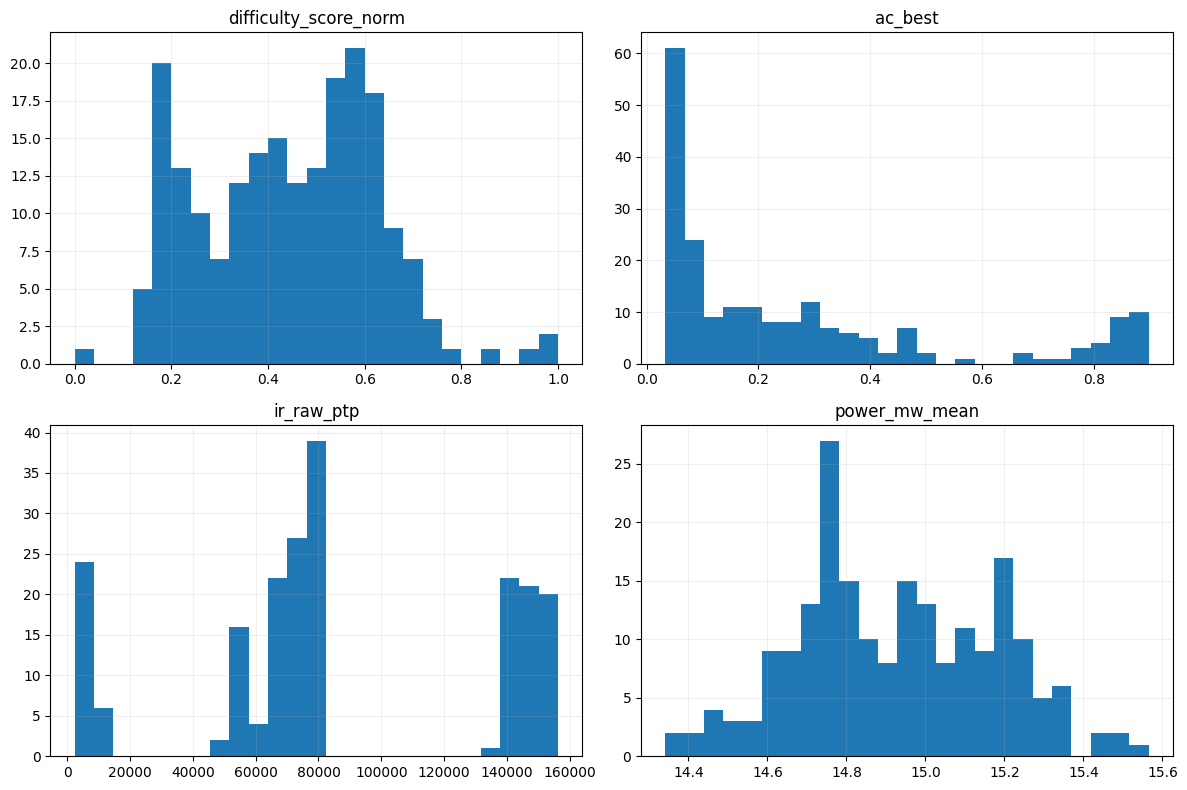

In [12]:
# Firmware-synced quality gates (Goldilocks, V7) for fair offline evaluation

quality_df = feature_df.copy()

# Mirror firmware macros in scheduler_compute_window_metrics (V7)
FW_SCHED_STD_MIN = 250.0
FW_SCHED_PTP_MIN = 1000.0
FW_SCHED_PTP_MAX = 120000.0
FW_SCHED_AC_MIN = 0.40

quality_df["gate_std_min"] = quality_df["ir_raw_std"] >= FW_SCHED_STD_MIN
quality_df["gate_ptp_min"] = quality_df["ir_raw_ptp"] >= FW_SCHED_PTP_MIN
quality_df["gate_ptp_max"] = quality_df["ir_raw_ptp"] <= FW_SCHED_PTP_MAX
quality_df["gate_ac"] = quality_df["ac_best"] >= FW_SCHED_AC_MIN

quality_df["quality_pass"] = (
    quality_df["gate_std_min"] &
    quality_df["gate_ptp_min"] &
    quality_df["gate_ptp_max"] &
    quality_df["gate_ac"]
)

gate_summary = pd.DataFrame({
    "gate": ["std_min", "ptp_min", "ptp_max", "ac", "all_pass"],
    "pass_ratio": [
        quality_df["gate_std_min"].mean(),
        quality_df["gate_ptp_min"].mean(),
        quality_df["gate_ptp_max"].mean(),
        quality_df["gate_ac"].mean(),
        quality_df["quality_pass"].mean(),
    ]
})
display(gate_summary)

profile_quality = quality_df.groupby(["profile_name", "condition"]).agg(
    windows=("quality_pass", "count"),
    quality_pass_ratio=("quality_pass", "mean"),
    power_mw_mean=("power_mw_mean", "mean"),
    difficulty_mean=("difficulty_score_norm", "mean"),
    ac_best_mean=("ac_best", "mean"),
    ir_ptp_mean=("ir_raw_ptp", "mean"),
).reset_index().sort_values(["profile_name", "condition"])

print("=== Profile-condition quality map (firmware-synced gate) ===")
display(profile_quality)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

axes[0].hist(feature_df["difficulty_score_norm"], bins=25)
axes[0].set_title("difficulty_score_norm")
axes[0].grid(alpha=0.2)

axes[1].hist(feature_df["ac_best"], bins=25)
axes[1].set_title("ac_best")
axes[1].grid(alpha=0.2)

axes[2].hist(feature_df["ir_raw_ptp"], bins=25)
axes[2].set_title("ir_raw_ptp")
axes[2].grid(alpha=0.2)

axes[3].hist(feature_df["power_mw_mean"], bins=25)
axes[3].set_title("power_mw_mean")
axes[3].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Baseline-wander check for firmware-like gate

Mục tiêu: kiểm tra trực tiếp giả thuyết trong `note.md` rằng gate dựa biên độ thô (`std`, `ptp`) đang bị nhiễu bởi baseline wander.

Cell tiếp theo sẽ so sánh metric raw vs detrended (subtract moving average) trên đúng các cửa sổ 8s/2s đã dùng ở trên.

In [74]:
# Compare firmware-like proxies: old (std+ptp) vs new (ac+ptp)
quality_df["difficulty_old_fw_like"] = 1.0 - 0.5 * (
    np.clip(quality_df["ir_raw_std"] / 4000.0, 0.0, 1.0) +
    np.clip(quality_df["ir_raw_ptp"] / 12000.0, 0.0, 1.0)
)

quality_df["difficulty_new_fw_like"] = (
    0.7 * (1.0 - np.clip(quality_df["ac_best"], 0.0, 1.0)) +
    0.3 * (1.0 - np.clip(quality_df["ir_raw_ptp"] / 6000.0, 0.0, 1.0))
)

proxy_cmp = quality_df.groupby("condition")[[
    "difficulty_old_fw_like",
    "difficulty_new_fw_like",
    "difficulty_score_norm",
    "ac_best",
    "ir_raw_ptp",
]].agg(["mean", "std"])

print("=== Proxy comparison by condition ===")
display(proxy_cmp)

corr_cols = ["difficulty_old_fw_like", "difficulty_new_fw_like", "difficulty_score_norm", "quality_pass", "ac_best", "ir_raw_ptp"]
proxy_corr = quality_df[corr_cols].corr(numeric_only=True)
print("\n=== Correlation matrix ===")
display(proxy_corr)

=== Proxy comparison by condition ===


difficulty_old_fw_like      difficulty_new_fw_like            \
                            mean  std                   mean       std   
condition                                                                
bad                          0.0  0.0                0.44759  0.103438   
good                         0.0  0.0                0.65503  0.014110   

          difficulty_score_norm             ac_best               ir_raw_ptp  \
                           mean       std      mean       std           mean   
condition                                                                      
bad                    0.501605  0.125283  0.360586  0.147769  143321.587629   
good                   0.566756  0.248802  0.064243  0.020157   69729.390805   

                         
                    std  
condition                
bad         5340.464611  
good       12927.311014


=== Correlation matrix ===


,difficulty_old_fw_like,difficulty_new_fw_like,difficulty_score_norm,quality_pass,ac_best,ir_raw_ptp
difficulty_old_fw_like,NaN,NaN,NaN,NaN,NaN,NaN
difficulty_new_fw_like,NaN,1.000000,0.252644,NaN,-1.000000,-0.804973
difficulty_score_norm,NaN,0.252644,1.000000,NaN,-0.252644,-0.136595
quality_pass,NaN,NaN,NaN,NaN,NaN,NaN
ac_best,NaN,-1.000000,-0.252644,NaN,1.000000,0.804973
ir_raw_ptp,NaN,-0.804973,-0.136595,NaN,0.804973,1.000000


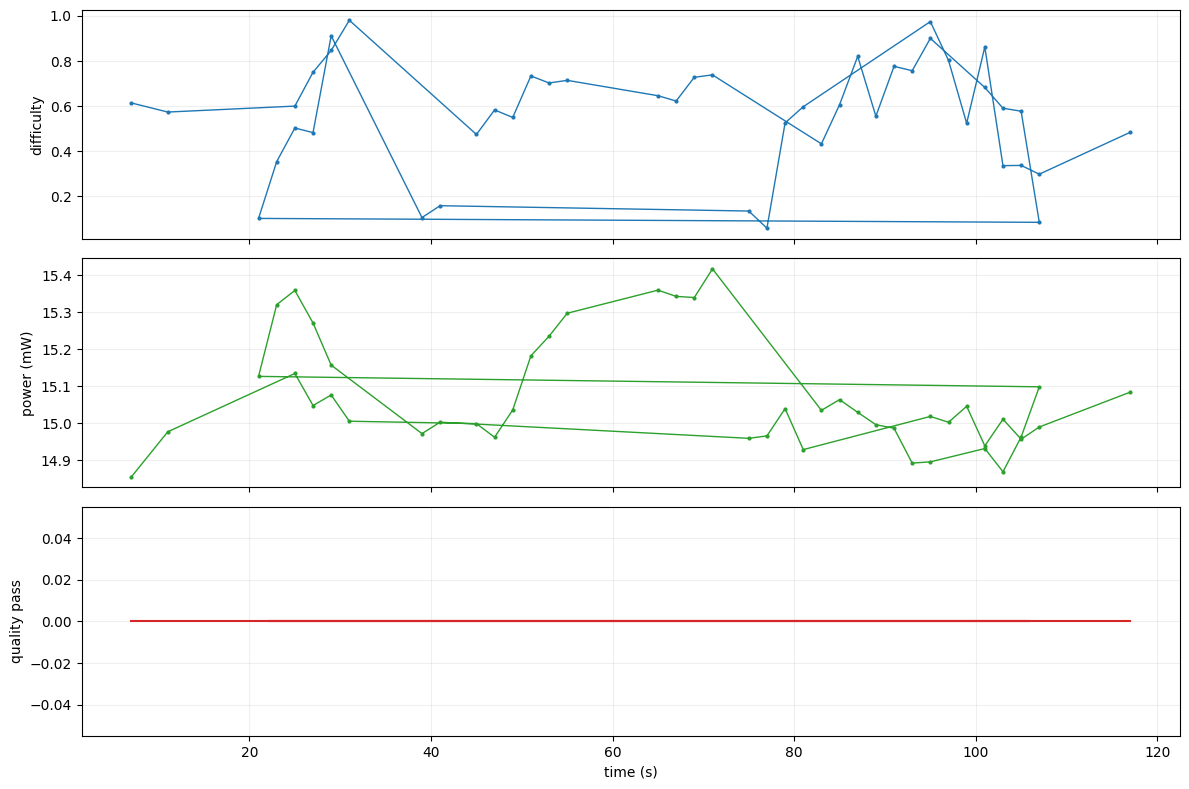

{'num_files': 12, 'total_rows_raw': 139983, 'total_windows': 184, 'overall_quality_pass_ratio': 0.0, 'profiles': ['100sps_med', '50sps_med', 'adaptive_50_100']}


In [75]:
# Timeline quick-look cho 1 run tiêu biểu

VIEW_PROFILE = "50sps_med"

VIEW_CONDITION = "good"



candidate = quality_df[(quality_df["profile_name"] == VIEW_PROFILE) & (quality_df["condition"] == VIEW_CONDITION)].copy()

if len(candidate) == 0:

    candidate = quality_df.copy()



view_df = candidate.sort_values(["file_name", "window_start_s"]).copy().reset_index(drop=True)

view_df["window_mid_s"] = (view_df["window_start_s"] + view_df["window_end_s"]) / 2.0



fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(view_df["window_mid_s"], view_df["difficulty_score_norm"], marker="o", markersize=2, linewidth=1)

axes[0].set_ylabel("difficulty")

axes[0].grid(alpha=0.2)



axes[1].plot(view_df["window_mid_s"], view_df["power_mw_mean"], marker="o", markersize=2, linewidth=1, color="tab:green")

axes[1].set_ylabel("power (mW)")

axes[1].grid(alpha=0.2)



axes[2].step(view_df["window_mid_s"], view_df["quality_pass"].astype(int), where="mid", color="tab:red")

axes[2].set_ylabel("quality pass")

axes[2].set_xlabel("time (s)")

axes[2].grid(alpha=0.2)



plt.tight_layout()

plt.show()



summary = {

    "num_files": int(file_stats_df.shape[0]),

    "total_rows_raw": int(len(raw_df)),

    "total_windows": int(len(feature_df)),

    "overall_quality_pass_ratio": float(quality_df["quality_pass"].mean()),

    "profiles": sorted(quality_df["profile_name"].unique().tolist()),

}

print(summary)

In [76]:
# Policy analysis for firmware v2 profile set (fallback-friendly)
preferred_profiles = ["50sps_low", "50sps_med", "100sps_med"]
available_profiles = sorted(quality_df["profile_name"].unique().tolist())
POLICY_PROFILES = [p for p in preferred_profiles if p in available_profiles]
if len(POLICY_PROFILES) < 2:
    POLICY_PROFILES = available_profiles

policy_df = quality_df[quality_df["profile_name"].isin(POLICY_PROFILES)].copy()

print("=== Policy map (window-level) ===")
policy_map_df = policy_df.groupby(["profile_name", "condition"]).agg(
    windows=("quality_pass", "size"),
    quality_pass_ratio=("quality_pass", "mean"),
    avg_power_mw=("power_mw_mean", "mean"),
    difficulty_mean=("difficulty_score_norm", "mean"),
    ac_best_mean=("ac_best", "mean"),
    ir_ptp_mean=("ir_raw_ptp", "mean"),
).reset_index().sort_values(["profile_name", "condition"])
display(policy_map_df)

# Run-level stats để báo cáo mean ± std theo nhiều run
run_level_df = policy_df.groupby(["profile_name", "condition", "run_idx", "file_name"]).agg(
    windows=("quality_pass", "size"),
    quality_pass_ratio=("quality_pass", "mean"),
    avg_power_mw=("power_mw_mean", "mean"),
    difficulty_mean=("difficulty_score_norm", "mean"),
).reset_index()

report_stats_df = run_level_df.groupby(["profile_name", "condition"]).agg(
    n_runs=("run_idx", "nunique"),
    windows_mean=("windows", "mean"),
    quality_pass_ratio_mean=("quality_pass_ratio", "mean"),
    quality_pass_ratio_std=("quality_pass_ratio", "std"),
    avg_power_mw_mean=("avg_power_mw", "mean"),
    avg_power_mw_std=("avg_power_mw", "std"),
    difficulty_mean_mean=("difficulty_mean", "mean"),
    difficulty_mean_std=("difficulty_mean", "std"),
).reset_index().sort_values(["profile_name", "condition"])

print("\n=== Report table (mean ± std over runs) ===")
display(report_stats_df)

decision3_df = policy_map_df[[
    "profile_name", "condition", "quality_pass_ratio", "avg_power_mw", "difficulty_mean", "windows"
]].copy()

good_rank3 = decision3_df[decision3_df["condition"] == "good"].sort_values(
    ["quality_pass_ratio", "avg_power_mw", "difficulty_mean"],
    ascending=[False, True, True]
).reset_index(drop=True)

bad_rank3 = decision3_df[decision3_df["condition"] == "bad"].sort_values(
    ["quality_pass_ratio", "difficulty_mean", "avg_power_mw"],
    ascending=[False, True, True]
).reset_index(drop=True)

print("\n=== Good ranking (available profiles) ===")
display(good_rank3)

print("=== Bad robustness ranking (available profiles) ===")
display(bad_rank3)

print("=== Firmware v2 direction: adaptive stays 2-state (50sps_med <-> 100sps_med), 50sps_low kept as fixed candidate ===")

=== Policy map (window-level) ===


,profile_name,condition,windows,quality_pass_ratio,avg_power_mw,difficulty_mean,ac_best_mean,ir_ptp_mean
0,100sps_med,bad,37,0.0,15.085649,0.517142,0.397948,143958.000000
1,100sps_med,good,30,0.0,15.062596,0.543149,0.062494,71566.033333
2,50sps_med,bad,38,0.0,15.046131,0.482648,0.346279,142688.421053
3,50sps_med,good,46,0.0,15.068814,0.569248,0.063681,69355.434783



=== Report table (mean ± std over runs) ===


,profile_name,condition,n_runs,windows_mean,quality_pass_ratio_mean,quality_pass_ratio_std,avg_power_mw_mean,avg_power_mw_std,difficulty_mean_mean,difficulty_mean_std
0,100sps_med,bad,2,18.5,0.0,0.0,15.086707,0.055373,0.517876,0.038417
1,100sps_med,good,2,15.0,0.0,0.0,15.042429,0.142604,0.547988,0.034213
2,50sps_med,bad,2,19.0,0.0,0.0,15.048626,0.067042,0.481919,0.019588
3,50sps_med,good,2,23.0,0.0,0.0,15.067541,0.010353,0.551600,0.143510



=== Good ranking (available profiles) ===


,profile_name,condition,quality_pass_ratio,avg_power_mw,difficulty_mean,windows
0,100sps_med,good,0.0,15.062596,0.543149,30
1,50sps_med,good,0.0,15.068814,0.569248,46


=== Bad robustness ranking (available profiles) ===


,profile_name,condition,quality_pass_ratio,avg_power_mw,difficulty_mean,windows
0,50sps_med,bad,0.0,15.046131,0.482648,38
1,100sps_med,bad,0.0,15.085649,0.517142,37


=== Firmware v2 direction: adaptive stays 2-state (50sps_med <-> 100sps_med), 50sps_low kept as fixed candidate ===


In [77]:
# Policy v1 spec (2-state) + threshold probe + threshold tuning
gate_probe_cols = ["ir_raw_std", "ir_raw_ptp", "ac_best", "difficulty_score_norm"]
threshold_probe = []
for col in gate_probe_cols:
    g = feature_df.groupby("condition")[col].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
    print(f"\n=== {col} by condition ===")
    display(g)

    good_q25 = float(feature_df.loc[feature_df["condition"] == "good", col].quantile(0.25))
    bad_q75 = float(feature_df.loc[feature_df["condition"] == "bad", col].quantile(0.75))
    threshold_probe.append({
        "feature": col,
        "good_q25": good_q25,
        "bad_q75": bad_q75,
    })

threshold_probe_df = pd.DataFrame(threshold_probe)
print("\n=== Threshold probe table (để tham chiếu khi chỉnh gate firmware) ===")
display(threshold_probe_df)

def simulate_two_state(policy_df, th_hard, th_easy, good_windows_to_down=3, cooldown_windows=1):
    base_profile = "50sps_med"
    high_profile = "100sps_med"
    sim_base = policy_df[policy_df["profile_name"] == base_profile].sort_values(["condition", "file_name", "window_start_s"]).reset_index(drop=True)
    if len(sim_base) == 0:
        return None

    lookup = policy_df[policy_df["profile_name"].isin([base_profile, high_profile])].groupby(["condition", "profile_name"]).agg(
        est_quality_pass=("quality_pass", "mean"),
        est_power_mw=("power_mw_mean", "mean"),
        est_difficulty=("difficulty_score_norm", "mean"),
    ).reset_index()

    lookup_q = {(r.condition, r.profile_name): float(r.est_quality_pass) for r in lookup.itertuples()}
    lookup_p = {(r.condition, r.profile_name): float(r.est_power_mw) for r in lookup.itertuples()}
    lookup_d = {(r.condition, r.profile_name): float(r.est_difficulty) for r in lookup.itertuples()}

    state = base_profile
    good_count = 0
    cooldown = 0
    rows = []

    for r in sim_base.itertuples():
        cond = r.condition
        diff = float(r.difficulty_score_norm)
        qpass = bool(r.quality_pass)
        switched = False

        if cooldown > 0:
            cooldown -= 1
        else:
            if state == base_profile:
                if (not qpass) or (diff >= th_hard):
                    state = high_profile
                    switched = True
                    good_count = 0
            else:
                if qpass and diff <= th_easy:
                    good_count += 1
                    if good_count >= good_windows_to_down:
                        state = base_profile
                        switched = True
                        good_count = 0
                else:
                    good_count = 0

        if switched:
            cooldown = cooldown_windows

        rows.append({
            "selected_profile": state,
            "condition": cond,
            "est_quality_pass": lookup_q.get((cond, state), np.nan),
            "est_power_mw": lookup_p.get((cond, state), np.nan),
            "est_difficulty": lookup_d.get((cond, state), np.nan),
        })

    sim_df_local = pd.DataFrame(rows)
    sim_df_local["est_quality_pass"] = sim_df_local["est_quality_pass"].fillna(0.0)
    sim_df_local["est_power_mw"] = sim_df_local["est_power_mw"].fillna(policy_df["power_mw_mean"].mean())
    sim_df_local["est_difficulty"] = sim_df_local["est_difficulty"].fillna(policy_df["difficulty_score_norm"].mean())

    base_q = float(policy_df[policy_df["profile_name"] == base_profile]["quality_pass"].mean())
    base_p = float(policy_df[policy_df["profile_name"] == base_profile]["power_mw_mean"].mean())
    high_p = float(policy_df[policy_df["profile_name"] == high_profile]["power_mw_mean"].mean())

    state_ratio = sim_df_local["selected_profile"].value_counts(normalize=True).to_dict()
    policy_power = float(sim_df_local["est_power_mw"].mean())
    policy_quality = float(sim_df_local["est_quality_pass"].mean())
    policy_diff = float(sim_df_local["est_difficulty"].mean())

    return {
        "difficulty_hard": float(th_hard),
        "difficulty_easy": float(th_easy),
        "downshift_good_windows": int(good_windows_to_down),
        "cooldown_windows": int(cooldown_windows),
        "policy_quality": policy_quality,
        "policy_power": policy_power,
        "policy_difficulty": policy_diff,
        "baseline_quality_50": base_q,
        "baseline_power_50": base_p,
        "baseline_power_100": high_p,
        "power_saving_vs_100_pct": 100.0 * (high_p - policy_power) / high_p if high_p > 1e-9 else np.nan,
        "power_delta_vs_50_pct": 100.0 * (policy_power - base_p) / base_p if base_p > 1e-9 else np.nan,
        "ratio_50": float(state_ratio.get(base_profile, 0.0)),
        "ratio_100": float(state_ratio.get(high_profile, 0.0)),
    }

# Tuning theo dữ liệu thật: ưu tiên quality không giảm quá mạnh so với fixed 50, rồi giảm power
candidates = []
for hard in [0.65, 0.70, 0.75, 0.80]:
    for easy in [0.45, 0.50, 0.55, 0.60]:
        if easy >= hard:
            continue
        for down_n in [2, 3, 4]:
            sim = simulate_two_state(policy_df, th_hard=hard, th_easy=easy, good_windows_to_down=down_n, cooldown_windows=1)
            if sim is not None:
                candidates.append(sim)

tuning_df = pd.DataFrame(candidates).sort_values(["policy_quality", "policy_power"], ascending=[False, True]).reset_index(drop=True)
display(tuning_df.head(12))

quality_floor = float(policy_df[policy_df["profile_name"] == "50sps_med"]["quality_pass"].mean()) - 0.02
feasible = tuning_df[tuning_df["policy_quality"] >= quality_floor].copy()

if len(feasible):
    best_row = feasible.sort_values(["policy_power", "policy_quality"], ascending=[True, False]).iloc[0]
else:
    best_row = tuning_df.iloc[0]

POLICY_V1_2STATE = {
    "state_normal": "50sps_med",
    "state_high": "100sps_med",
    "window_sec": 8.0,
    "stride_sec": 2.0,
    "difficulty_hard": float(best_row["difficulty_hard"]),
    "difficulty_easy": float(best_row["difficulty_easy"]),
    "upshift_on_quality_fail": True,
    "downshift_good_windows": int(best_row["downshift_good_windows"]),
    "cooldown_windows_after_switch": int(best_row["cooldown_windows"]),
}

print("\n=== Selected POLICY_V1_2STATE ===")
display(POLICY_V1_2STATE)


=== ir_raw_std by condition ===


,count,mean,std,min,10%,25%,50%,75%,90%,max
condition,,,,,,,,,,
bad,97.0,45772.489852,4235.949437,36845.566406,40979.107812,42616.363281,45441.742188,49184.468750,51131.690625,57338.910156
good,87.0,25355.014525,2834.354670,20971.480469,22770.131250,23165.493164,24713.400391,27049.407227,29441.084375,31714.373047



=== ir_raw_ptp by condition ===


,count,mean,std,min,10%,25%,50%,75%,90%,max
condition,,,,,,,,,,
bad,97.0,143321.587629,5340.464611,124163.0,135973.4,140264.0,144018.0,147785.0,148776.6,156232.0
good,87.0,69729.390805,12927.311014,53474.0,57193.0,58711.0,65859.0,76014.0,83613.0,108373.0



=== ac_best by condition ===


...


=== Threshold probe table (để tham chiếu khi chỉnh gate firmware) ===


,feature,good_q25,bad_q75
0,ir_raw_std,23165.493164,49184.468750
1,ir_raw_ptp,58711.000000,147785.000000
2,ac_best,0.049279,0.477921
3,difficulty_score_norm,0.414782,0.588722


,difficulty_hard,difficulty_easy,downshift_good_windows,cooldown_windows,policy_quality,policy_power,policy_difficulty,baseline_quality_50,baseline_power_50,baseline_power_100,power_saving_vs_100_pct,power_delta_vs_50_pct,ratio_50,ratio_100
0,0.65,0.45,2,1,0.0,15.073025,0.531384,0.0,15.058552,15.075327,0.01527,0.096107,0.0,1.0
1,0.65,0.45,3,1,0.0,15.073025,0.531384,0.0,15.058552,15.075327,0.01527,0.096107,0.0,1.0
2,0.65,0.45,4,1,0.0,15.073025,0.531384,0.0,15.058552,15.075327,0.01527,0.096107,0.0,1.0
3,0.65,0.50,2,1,0.0,15.073025,0.531384,0.0,15.058552,15.075327,0.01527,0.096107,0.0,1.0
4,0.65,0.50,3,1,0.0,15.073025,0.531384,0.0,15.058552,15.075327,0.01527,0.096107,0.0,1.0
5,0.65,0.50,4,1,0.0,15.073025,0.531384,0.0,15.058552,15.075327,0.01527,0.096107,0.0,1.0
6,0.65,0.55,2,1,0.0,15.073025,0.531384,0.0,15.058552,15.075327,0.01527,0.096107,0.0,1.0
7,0.65,0.55,3,1,0.0,15.073025,0.531384,0.0,15.058552,15.075327,0.01527,0.096107,0.0,1.0
8,0.65,0.55,4,1,0.0,15.073025,0.531384,0.0,15.058552,15.075327,0.01527,0.096107,0.0,1.0
9,0.65,0.60,2,1,0.0,15.073025,0.531384,0.0,15.058552,15.075327,0.01527,0.096107,0.0,1.0



=== Selected POLICY_V1_2STATE ===


{'state_normal': '50sps_med',
 'state_high': '100sps_med',
 'window_sec': 8.0,
 'stride_sec': 2.0,
 'difficulty_hard': 0.65,
 'difficulty_easy': 0.45,
 'upshift_on_quality_fail': True,
 'downshift_good_windows': 2,
 'cooldown_windows_after_switch': 1}

In [78]:
# Scheduler simulation v1 (2-state: 50sps_med <-> 100sps_med, using tuned POLICY_V1_2STATE)
BASE_PROFILE = POLICY_V1_2STATE["state_normal"]
HIGH_PROFILE = POLICY_V1_2STATE["state_high"]
TH_HARD = float(POLICY_V1_2STATE["difficulty_hard"])
TH_EASY = float(POLICY_V1_2STATE["difficulty_easy"])
GOOD_WINDOWS_TO_DOWN = int(POLICY_V1_2STATE["downshift_good_windows"])
COOLDOWN_WINDOWS = int(POLICY_V1_2STATE["cooldown_windows_after_switch"])

sim_base = policy_df[(policy_df["profile_name"] == BASE_PROFILE)].copy()
sim_base = sim_base.sort_values(["condition", "file_name", "window_start_s"]).reset_index(drop=True)
assert len(sim_base) > 0, "Không có window từ 50sps_med để mô phỏng scheduler"

lookup = policy_df[policy_df["profile_name"].isin([BASE_PROFILE, HIGH_PROFILE])].groupby(["condition", "profile_name"]).agg(
    est_quality_pass=("quality_pass", "mean"),
    est_power_mw=("power_mw_mean", "mean"),
    est_difficulty=("difficulty_score_norm", "mean"),
).reset_index()

lookup_q = {(r.condition, r.profile_name): float(r.est_quality_pass) for r in lookup.itertuples()}
lookup_p = {(r.condition, r.profile_name): float(r.est_power_mw) for r in lookup.itertuples()}
lookup_d = {(r.condition, r.profile_name): float(r.est_difficulty) for r in lookup.itertuples()}

state = BASE_PROFILE
good_count = 0
cooldown = 0
sim_rows = []

for r in sim_base.itertuples():
    cond = r.condition
    diff = float(r.difficulty_score_norm)
    qpass = bool(r.quality_pass)
    switched = False

    if cooldown > 0:
        cooldown -= 1
    else:
        if state == BASE_PROFILE:
            if (not qpass) or (diff >= TH_HARD):
                state = HIGH_PROFILE
                switched = True
                good_count = 0
        else:
            if qpass and diff <= TH_EASY:
                good_count += 1
                if good_count >= GOOD_WINDOWS_TO_DOWN:
                    state = BASE_PROFILE
                    switched = True
                    good_count = 0
            else:
                good_count = 0

    if switched:
        cooldown = COOLDOWN_WINDOWS

    sim_rows.append({
        "condition": cond,
        "file_name": r.file_name,
        "window_start_s": float(r.window_start_s),
        "driver_difficulty": diff,
        "driver_quality_pass": int(qpass),
        "selected_profile": state,
        "est_quality_pass": lookup_q.get((cond, state), np.nan),
        "est_power_mw": lookup_p.get((cond, state), np.nan),
        "est_difficulty": lookup_d.get((cond, state), np.nan),
    })

sim_df = pd.DataFrame(sim_rows)
sim_df["est_quality_pass"] = sim_df["est_quality_pass"].fillna(0.0)
sim_df["est_power_mw"] = sim_df["est_power_mw"].fillna(policy_df["power_mw_mean"].mean())
sim_df["est_difficulty"] = sim_df["est_difficulty"].fillna(policy_df["difficulty_score_norm"].mean())

state_ratio = sim_df["selected_profile"].value_counts(normalize=True).rename("time_ratio").reset_index()
state_ratio.columns = ["selected_profile", "time_ratio"]

profile_power = policy_df.groupby("profile_name")["power_mw_mean"].mean().to_dict()
policy_avg_power = float(sim_df["est_power_mw"].mean())
fixed_power_50 = float(profile_power.get(BASE_PROFILE, np.nan))
fixed_power_100 = float(profile_power.get(HIGH_PROFILE, np.nan))

saving_vs_100_pct = 100.0 * (fixed_power_100 - policy_avg_power) / fixed_power_100 if np.isfinite(fixed_power_100) and fixed_power_100 > 1e-9 else np.nan
delta_vs_50_pct = 100.0 * (policy_avg_power - fixed_power_50) / fixed_power_50 if np.isfinite(fixed_power_50) and fixed_power_50 > 1e-9 else np.nan

sim_summary = pd.DataFrame([{
    "windows": int(len(sim_df)),
    "estimated_quality_pass_ratio_under_policy": float(sim_df["est_quality_pass"].mean()),
    "estimated_difficulty_under_policy": float(sim_df["est_difficulty"].mean()),
    "policy_avg_power_mw": policy_avg_power,
    "fixed_50_avg_power_mw": fixed_power_50,
    "fixed_100_avg_power_mw": fixed_power_100,
    "power_saving_vs_fixed100_pct": float(saving_vs_100_pct),
    "power_delta_vs_fixed50_pct": float(delta_vs_50_pct),
}])

print("=== Selected policy params ===")
print(POLICY_V1_2STATE)

print("\n=== Scheduler v1 (2-state) state ratio ===")
display(state_ratio)

print("=== Scheduler v1 (2-state) KPI summary ===")
display(sim_summary)

=== Selected policy params ===
{'state_normal': '50sps_med', 'state_high': '100sps_med', 'window_sec': 8.0, 'stride_sec': 2.0, 'difficulty_hard': 0.65, 'difficulty_easy': 0.45, 'upshift_on_quality_fail': True, 'downshift_good_windows': 2, 'cooldown_windows_after_switch': 1}

=== Scheduler v1 (2-state) state ratio ===


,selected_profile,time_ratio
0,100sps_med,1.0


=== Scheduler v1 (2-state) KPI summary ===


,windows,estimated_quality_pass_ratio_under_policy,estimated_difficulty_under_policy,policy_avg_power_mw,fixed_50_avg_power_mw,fixed_100_avg_power_mw,power_saving_vs_fixed100_pct,power_delta_vs_fixed50_pct
0,84,0.0,0.531384,15.073025,15.058552,15.075327,0.01527,0.096107


In [13]:
# Experiment summary theo nhóm mode chuẩn hoá (fixed_50_low / fixed_50_med / fixed_100 / adaptive)
exp_summary_df = quality_df.groupby(["exp_group", "condition"]).agg(
    windows=("quality_pass", "size"),
    quality_pass_ratio=("quality_pass", "mean"),
    avg_power_mw=("power_mw_mean", "mean"),
    difficulty_mean=("difficulty_score_norm", "mean"),
    ac_best_mean=("ac_best", "mean"),
).reset_index().sort_values(["condition", "exp_group"])
,
print("=== A/B/C summary by mode-condition ===")
display(exp_summary_df)

adaptive_rows = raw_df[raw_df["exp_group"] == "adaptive"].copy()
adaptive_rows = adaptive_rows[adaptive_rows["state_id"] >= 0].copy()

if len(adaptive_rows) > 0:
    adaptive_state_ratio = adaptive_rows.groupby(["condition", "state_id"]).size().rename("rows").reset_index()
    adaptive_state_ratio["time_ratio"] = adaptive_state_ratio.groupby("condition")["rows"].transform(lambda x: x / x.sum())
    state_name_map = {0: "normal(50sps)", 1: "high(100sps)"}
    adaptive_state_ratio["state_name"] = adaptive_state_ratio["state_id"].map(state_name_map).fillna("unknown")

    print("\n=== Adaptive state occupancy (from on-device logs) ===")
    display(adaptive_state_ratio[["condition", "state_id", "state_name", "rows", "time_ratio"]])
else:
    print("\nKhông có state_id hợp lệ trong adaptive logs để tính occupancy")

power_pivot = exp_summary_df.pivot(index="condition", columns="exp_group", values="avg_power_mw")
quality_pivot = exp_summary_df.pivot(index="condition", columns="exp_group", values="quality_pass_ratio")

baseline_50_col = "fixed_50_med" if "fixed_50_med" in power_pivot.columns else ("fixed_50_low" if "fixed_50_low" in power_pivot.columns else None)

if {"fixed_100", "adaptive"}.issubset(set(power_pivot.columns)):
    compare_df = pd.DataFrame(index=power_pivot.index)
    compare_df["adaptive_power_vs_fixed100_saving_pct"] = 100.0 * (power_pivot["fixed_100"] - power_pivot["adaptive"]) / power_pivot["fixed_100"]
    if baseline_50_col is not None:
        compare_df[f"adaptive_power_vs_{baseline_50_col}_delta_pct"] = 100.0 * (power_pivot["adaptive"] - power_pivot[baseline_50_col]) / power_pivot[baseline_50_col]
    if {"fixed_100", "adaptive"}.issubset(set(quality_pivot.columns)):
        compare_df["adaptive_quality_minus_fixed100"] = quality_pivot["adaptive"] - quality_pivot["fixed_100"]
    if baseline_50_col is not None:
        compare_df[f"adaptive_quality_minus_{baseline_50_col}"] = quality_pivot["adaptive"] - quality_pivot[baseline_50_col]

    print("\n=== Adaptive benefit/penalty vs baselines ===")
    display(compare_df.reset_index())

=== A/B/C summary by mode-condition ===


,exp_group,condition,windows,quality_pass_ratio,avg_power_mw,difficulty_mean,ac_best_mean
0,adaptive,bad,17,0.000,15.030476,0.505032,0.357946
2,fixed_100,bad,16,0.000,14.986920,0.512027,0.279338
4,fixed_50_med,bad,31,0.000,15.108771,0.526869,0.311806
1,adaptive,good,80,0.375,14.779166,0.337326,0.384103
3,fixed_100,good,23,0.000,14.945725,0.519379,0.062060
5,fixed_50_med,good,37,0.000,14.994743,0.502267,0.054907



=== Adaptive state occupancy (from on-device logs) ===


,condition,state_id,state_name,rows,time_ratio
0,bad,0,normal(50sps),598,0.024528
1,bad,1,high(100sps),23782,0.975472
2,good,0,normal(50sps),16597,0.459687
3,good,1,high(100sps),19508,0.540313



=== Adaptive benefit/penalty vs baselines ===


,condition,adaptive_power_vs_fixed100_saving_pct,adaptive_power_vs_fixed_50_med_delta_pct,adaptive_quality_minus_fixed100,adaptive_quality_minus_fixed_50_med
0,bad,-0.290622,-0.518210,0.000,0.000
1,good,1.114421,-1.437682,0.375,0.375


In [14]:
# Firmware-like raw vs detrended gate diagnostics (optimized + V7 synced gate)
PROFILE_ID_TO_FS = {0: 100.0, 1: 50.0, 2: 50.0}

def moving_average_highpass(x, fs_hz, ma_sec=1.0):
    x = np.asarray(x, dtype=np.float32)
    k = max(3, int(fs_hz * ma_sec))
    if (k % 2) == 0:
        k += 1
    kernel = np.ones(k, dtype=np.float32) / float(k)
    trend = np.convolve(x, kernel, mode="same")
    return (x - trend).astype(np.float32)

def ac_best_from_signal(x, fs_hz, bpm_min=40, bpm_max=180):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < 32 or fs_hz <= 1:
        return 0.0
    ac = normalized_autocorr(x)
    lag_min = max(1, int(fs_hz * 60 / bpm_max))
    lag_max = min(int(fs_hz * 60 / bpm_min), len(ac) - 1)
    if lag_max <= lag_min:
        return 0.0
    return float(np.max(ac[lag_min:lag_max + 1]))

# cache per-file arrays for fast slicing
file_cache = {}
for fn, g in raw_df.groupby("file_name"):
    g = g.sort_values("time_s")
    file_cache[fn] = {
        "time_s": g["time_s"].to_numpy(dtype=np.float64),
        "ir": g["ir"].to_numpy(dtype=np.float32),
        "profile_id": g["profile_id"].to_numpy(dtype=np.int16),
    }

gate_rows = []
for r in feature_df.itertuples():
    cache = file_cache.get(r.file_name)
    if cache is None:
        continue

    t = cache["time_s"]
    i0 = int(np.searchsorted(t, r.window_start_s, side="left"))
    i1 = int(np.searchsorted(t, r.window_end_s, side="left"))
    if (i1 - i0) < 40:
        continue

    ir = cache["ir"][i0:i1]
    profile_ids = cache["profile_id"][i0:i1]
    profile_id_mode = int(pd.Series(profile_ids).mode().iloc[0])
    fs_hz = float(PROFILE_ID_TO_FS.get(profile_id_mode, 50.0))

    ir_hp = moving_average_highpass(ir, fs_hz=fs_hz, ma_sec=1.0)

    std_raw = float(np.std(ir))
    ptp_raw = float(np.ptp(ir))
    ac_raw = ac_best_from_signal(ir, fs_hz)

    std_hp = float(np.std(ir_hp))
    ptp_hp = float(np.ptp(ir_hp))
    ac_hp = ac_best_from_signal(ir_hp, fs_hz)

    gate_rows.append({
        "file_name": r.file_name,
        "condition": r.condition,
        "profile_name": r.profile_name,
        "exp_group": r.exp_group,
        "window_start_s": float(r.window_start_s),
        "window_end_s": float(r.window_end_s),
        "power_mw_mean": float(r.power_mw_mean),
        "std_raw": std_raw,
        "ptp_raw": ptp_raw,
        "ac_raw": ac_raw,
        "std_hp": std_hp,
        "ptp_hp": ptp_hp,
        "ac_hp": ac_hp,
    })

fw_gate_df = pd.DataFrame(gate_rows)
assert len(fw_gate_df) > 0, "fw_gate_df rỗng"

std_raw_th = float(fw_gate_df["std_raw"].quantile(0.35))
ptp_raw_th = float(fw_gate_df["ptp_raw"].quantile(0.35))
ac_raw_th = float(fw_gate_df["ac_raw"].quantile(0.35))

std_hp_th = float(fw_gate_df["std_hp"].quantile(0.35))
ptp_hp_th = float(fw_gate_df["ptp_hp"].quantile(0.35))
ac_hp_th = float(fw_gate_df["ac_hp"].quantile(0.35))

fw_gate_df["pass_raw_gate"] = (
    (fw_gate_df["std_raw"] >= std_raw_th) &
    (fw_gate_df["ptp_raw"] >= ptp_raw_th) &
    (fw_gate_df["ac_raw"] >= ac_raw_th)
).astype(int)

fw_gate_df["pass_hp_gate"] = (
    (fw_gate_df["std_hp"] >= std_hp_th) &
    (fw_gate_df["ptp_hp"] >= ptp_hp_th) &
    (fw_gate_df["ac_hp"] >= ac_hp_th)
).astype(int)

# Firmware-synced V7 Goldilocks gate on detrended metrics
FW_SCHED_STD_MIN = 250.0
FW_SCHED_PTP_MIN = 1000.0
FW_SCHED_PTP_MAX = 120000.0
FW_SCHED_AC_MIN = 0.40

fw_gate_df["pass_fw_v6"] = (
    (fw_gate_df["std_hp"] >= FW_SCHED_STD_MIN) &
    (fw_gate_df["ptp_hp"] >= FW_SCHED_PTP_MIN) &
    (fw_gate_df["ptp_hp"] <= FW_SCHED_PTP_MAX) &
    (fw_gate_df["ac_hp"] >= FW_SCHED_AC_MIN)
).astype(int)

gate_cmp = fw_gate_df.groupby("condition").agg(
    n_windows=("pass_raw_gate", "size"),
    pass_raw_ratio=("pass_raw_gate", "mean"),
    pass_hp_ratio=("pass_hp_gate", "mean"),
    pass_fw_v6_ratio=("pass_fw_v6", "mean"),
    ac_raw_mean=("ac_raw", "mean"),
    ac_hp_mean=("ac_hp", "mean"),
    ptp_raw_mean=("ptp_raw", "mean"),
    ptp_hp_mean=("ptp_hp", "mean"),
).reset_index()

threshold_ref = pd.DataFrame([
    {"metric": "std_raw_th", "value": std_raw_th},
    {"metric": "ptp_raw_th", "value": ptp_raw_th},
    {"metric": "ac_raw_th", "value": ac_raw_th},
    {"metric": "std_hp_th", "value": std_hp_th},
    {"metric": "ptp_hp_th", "value": ptp_hp_th},
    {"metric": "ac_hp_th", "value": ac_hp_th},
    {"metric": "FW_SCHED_STD_MIN", "value": FW_SCHED_STD_MIN},
    {"metric": "FW_SCHED_PTP_MIN", "value": FW_SCHED_PTP_MIN},
    {"metric": "FW_SCHED_PTP_MAX", "value": FW_SCHED_PTP_MAX},
    {"metric": "FW_SCHED_AC_MIN", "value": FW_SCHED_AC_MIN},
])

print("=== Raw vs detrended gate comparison ===")
display(gate_cmp)
print("\n=== Relative threshold references (percentile-based + firmware V7) ===")
display(threshold_ref)

=== Raw vs detrended gate comparison ===


,condition,n_windows,pass_raw_ratio,pass_hp_ratio,pass_fw_v6_ratio,ac_raw_mean,ac_hp_mean,ptp_raw_mean,ptp_hp_mean
0,bad,64,0.125000,0.734375,0.000000,0.488934,0.454872,147438.390625,187743.364502
1,good,140,0.357143,0.307143,0.421429,0.816814,0.547839,56744.607143,100446.057701



=== Relative threshold references (percentile-based + firmware V7) ===


,metric,value
0,std_raw_th,22391.151074
1,ptp_raw_th,69176.450000
2,ac_raw_th,0.587634
3,std_hp_th,22245.314746
4,ptp_hp_th,111116.673047
5,ac_hp_th,0.367689
6,FW_SCHED_STD_MIN,250.000000
7,FW_SCHED_PTP_MIN,1000.000000
8,FW_SCHED_PTP_MAX,120000.000000
9,FW_SCHED_AC_MIN,0.400000


In [15]:
# Suggest firmware threshold candidates from detrended metrics
def pick_threshold_between(good_vals, bad_vals, favor="recall_good"):
    good_vals = np.asarray(good_vals, dtype=np.float64)
    bad_vals = np.asarray(bad_vals, dtype=np.float64)
    if len(good_vals) == 0 or len(bad_vals) == 0:
        return np.nan
    if favor == "recall_good":
        return float(np.quantile(good_vals, 0.20))
    return float(0.5 * (np.quantile(good_vals, 0.5) + np.quantile(bad_vals, 0.5)))

good = fw_gate_df[fw_gate_df["condition"] == "good"]
bad = fw_gate_df[fw_gate_df["condition"] == "bad"]

suggest_std_min = pick_threshold_between(good["std_hp"], bad["std_hp"], favor="recall_good")
suggest_ptp_min = pick_threshold_between(good["ptp_hp"], bad["ptp_hp"], favor="recall_good")
suggest_ac_min = pick_threshold_between(good["ac_hp"], bad["ac_hp"], favor="recall_good")

threshold_suggest_df = pd.DataFrame([
    {"firmware_macro": "SCHED_STD_MIN", "suggest_value": suggest_std_min, "metric_source": "std_hp"},
    {"firmware_macro": "SCHED_PTP_MIN", "suggest_value": suggest_ptp_min, "metric_source": "ptp_hp"},
    {"firmware_macro": "SCHED_AC_MIN", "suggest_value": suggest_ac_min, "metric_source": "ac_hp"},
])

print("=== Suggested firmware thresholds (from detrended window metrics) ===")
display(threshold_suggest_df)

# Kiểm tra pass ratio nếu dùng bộ ngưỡng gợi ý trên detrended metrics
fw_gate_df["pass_hp_suggested"] = (
    (fw_gate_df["std_hp"] >= suggest_std_min) &
    (fw_gate_df["ptp_hp"] >= suggest_ptp_min) &
    (fw_gate_df["ac_hp"] >= suggest_ac_min)
).astype(int)

suggest_eval = fw_gate_df.groupby("condition").agg(
    windows=("pass_hp_suggested", "size"),
    pass_ratio_suggested=("pass_hp_suggested", "mean"),
).reset_index()

print("\n=== Suggested-threshold pass ratio by condition ===")
display(suggest_eval)

=== Suggested firmware thresholds (from detrended window metrics) ===


,firmware_macro,suggest_value,metric_source
0,SCHED_STD_MIN,9048.711328,std_hp
1,SCHED_PTP_MIN,69465.875000,ptp_hp
2,SCHED_AC_MIN,0.158793,ac_hp



=== Suggested-threshold pass ratio by condition ===


,condition,windows,pass_ratio_suggested
0,bad,64,1.000000
1,good,140,0.621429


In [82]:
# Compact V4 verdict summary (for quick review)
import numpy as np
import pandas as pd

print(f"EXP_DIR = {EXP_DIR}")

compact = {}
compact["exp_version"] = str(EXP_DIR.name)
compact["n_files"] = int(experiment_df.shape[0])
compact["n_rows"] = int(raw_df.shape[0])
compact["n_windows"] = int(feature_df.shape[0])
compact["overall_quality_pass"] = float(quality_df["quality_pass"].mean())

# A/B style summary from exp_group
ab = quality_df.groupby(["exp_group", "condition"]).agg(
    quality_pass_ratio=("quality_pass", "mean"),
    power_mw=("power_mw_mean", "mean"),
    windows=("quality_pass", "size"),
).reset_index()

print("\n=== AB summary (compact) ===")
display(ab.round(4))

# Adaptive occupancy from raw state
if "adaptive_rows" in globals() and len(adaptive_rows) > 0:
    occ = adaptive_rows.groupby(["condition", "state_id"]).size().rename("rows").reset_index()
    occ["ratio"] = occ.groupby("condition")["rows"].transform(lambda x: x / x.sum())
    print("\n=== Adaptive occupancy (compact) ===")
    display(occ.round(4))

# Compare adaptive vs fixed_100
pivot_q = ab.pivot(index="condition", columns="exp_group", values="quality_pass_ratio")
pivot_p = ab.pivot(index="condition", columns="exp_group", values="power_mw")

if {"adaptive", "fixed_100"}.issubset(set(pivot_q.columns)):
    cmp = pd.DataFrame(index=pivot_q.index)
    cmp["quality_adaptive_minus_fixed100"] = pivot_q["adaptive"] - pivot_q["fixed_100"]
    cmp["power_saving_vs_fixed100_pct"] = 100.0 * (pivot_p["fixed_100"] - pivot_p["adaptive"]) / pivot_p["fixed_100"]
    print("\n=== Adaptive vs Fixed100 (compact) ===")
    display(cmp.round(4))

# Suggested thresholds from existing notebook variables
if "threshold_suggest_df" in globals():
    print("\n=== Suggested threshold candidates (compact) ===")
    display(threshold_suggest_df.round(4))

if "suggest_eval" in globals():
    print("\n=== Suggested threshold pass ratio (compact) ===")
    display(suggest_eval.round(4))

print("\n=== Headline metrics ===")
print(compact)

EXP_DIR = C:\ml\kaggle-ml-basics\log\exp_v6

=== AB summary (compact) ===


,exp_group,condition,quality_pass_ratio,power_mw,windows
0,adaptive,bad,0.0,15.0343,22
1,adaptive,good,0.0,15.0814,11
2,fixed_100,bad,0.0,15.0856,37
3,fixed_100,good,0.0,15.0626,30
4,fixed_50_med,bad,0.0,15.0461,38
5,fixed_50_med,good,0.0,15.0688,46



=== Adaptive occupancy (compact) ===


,condition,state_id,rows,ratio
0,bad,0,1798,0.0806
1,bad,1,20507,0.9194
2,good,0,5798,0.2419
3,good,1,18168,0.7581



=== Adaptive vs Fixed100 (compact) ===


...


=== Suggested threshold candidates (compact) ===


,firmware_macro,suggest_value,metric_source
0,SCHED_STD_MIN,23856.2457,std_hp
1,SCHED_PTP_MIN,110701.8578,ptp_hp
2,SCHED_AC_MIN,0.6916,ac_hp



=== Suggested threshold pass ratio (compact) ===


,condition,windows,pass_ratio_suggested
0,bad,97,0.0825
1,good,87,0.5057



=== Headline metrics ===
{'exp_version': 'exp_v6', 'n_files': 12, 'n_rows': 139983, 'n_windows': 184, 'overall_quality_pass': 0.0}


In [16]:
# Text-only compact summary for LLM reading (exp_v*)
import pandas as pd
import numpy as np

print(f"EXP_DIR={EXP_DIR}")
print(f"n_files={len(experiment_df)}, n_rows={len(raw_df)}, n_windows={len(feature_df)}")

use_fw_v6 = ("fw_gate_df" in globals()) and ("pass_fw_v6" in fw_gate_df.columns)
if use_fw_v6:
    eval_df = fw_gate_df.copy()
    eval_df["quality_eval"] = eval_df["pass_fw_v6"].astype(float)
    print("quality_metric=firmware_synced_v7_goldilocks_on_detrended")
else:
    eval_df = quality_df.copy()
    eval_df["quality_eval"] = eval_df["quality_pass"].astype(float)
    print("quality_metric=legacy_notebook_quality_pass")

print(f"overall_quality_pass={eval_df['quality_eval'].mean():.4f}")

ab = eval_df.groupby(['exp_group','condition']).agg(
    quality_pass_ratio=('quality_eval','mean'),
    power_mw=('power_mw_mean','mean'),
    windows=('quality_eval','size')
).reset_index().sort_values(['exp_group','condition'])

print("\n[AB]")
print(ab.to_string(index=False))

if 'adaptive_rows' in globals() and len(adaptive_rows) > 0:
    occ = adaptive_rows.groupby(['condition','state_id']).size().rename('rows').reset_index()
    occ['ratio'] = occ.groupby('condition')['rows'].transform(lambda x: x / x.sum())
    print("\n[OCC]")
    print(occ.to_string(index=False))

pivot_q = ab.pivot(index='condition', columns='exp_group', values='quality_pass_ratio')
pivot_p = ab.pivot(index='condition', columns='exp_group', values='power_mw')
if {'adaptive','fixed_100'}.issubset(set(pivot_q.columns)):
    cmp = pd.DataFrame(index=pivot_q.index)
    cmp['quality_adaptive_minus_fixed100'] = pivot_q['adaptive'] - pivot_q['fixed_100']
    cmp['power_saving_vs_fixed100_pct'] = 100.0 * (pivot_p['fixed_100'] - pivot_p['adaptive']) / pivot_p['fixed_100']
    print("\n[CMP]")
    print(cmp.reset_index().to_string(index=False))

if 'suggest_eval' in globals():
    print("\n[SUGGEST_EVAL]")
    print(suggest_eval.to_string(index=False))

EXP_DIR=C:\ml\kaggle-ml-basics\log\exp_v7
n_files=13, n_rows=157366, n_windows=204
quality_metric=firmware_synced_v7_goldilocks_on_detrended
overall_quality_pass=0.2892

[AB]
   exp_group condition  quality_pass_ratio  power_mw  windows
    adaptive       bad            0.000000 15.030476       17
    adaptive      good            0.237500 14.779166       80
   fixed_100       bad            0.000000 14.986920       16
   fixed_100      good            0.521739 14.945725       23
fixed_50_med       bad            0.000000 15.108771       31
fixed_50_med      good            0.756757 14.994743       37

[OCC]
condition  state_id  rows    ratio
      bad         0   598 0.024528
      bad         1 23782 0.975472
     good         0 16597 0.459687
     good         1 19508 0.540313

[CMP]
condition  quality_adaptive_minus_fixed100  power_saving_vs_fixed100_pct
      bad                         0.000000                     -0.290622
     good                        -0.284239              